# UFC Fight Data - Evaluación Parcial 2 Mineria de Datos

## Información del Grupo

- **Nombre o Número de Grupo:** Dana White
- **Sección:** 001D
- **Fecha de Entrega:** 27-05-2026

---

## Integrantes del Grupo

### Estudiante 1
- **Nombre:** Fabian
- **Apellido:** Armijo
- **Correo institucional:** fa.armijo@duocuc.cl

### Estudiante 2
- **Nombre:** Vicente
- **Apellido:** Balladares
- **Correo institucional:** vi.balladares@duocuc.cl


---

## Tema del Proyecto
La UFC es un entorno deportivo de alta incertidumbre y muy dinamico, a tal punto que un peleador puede ganar de solo un golpe. El problema analítico que vamos a trabajar radica en la dificultad que enfrentan promotores, analistas y apostadores para mitigar el riesgo y predecir de manera científica qué competidor posee mayor probabilidad de ganar la pelea basándose en sus edades, estaturas, alcances de brazos y lo que decían las apuestas.

---

## Finalidad y objetivo de nuestro trabajo
La finalidad de este trabajo es tomar el registro histórico de combates de la UFC que hay en el dataset, realizar una auditoría de calidad de datos y entrenar modelos analíticos. El objetivo matemático es encontrar las fronteras de decisión óptimas que separan a un peleador ganador de uno perdedor en función de sus diferencias físicas y del comportamiento del mercado de apuestas.

Nuestra meta (Variable Objetivo): Predecir red_winner (Si es 1/True, ganó el Rojo; si es 0/False, ganó el Azul).

---

## Introducción a la Metodología

## Descripción del Proyecto

### Contexto del Problema
Las artes marciales mixtas son un deporte de alta competencia e incertidumbre, donde el resultado de una pelea puede cambiar por completo debido a un solo golpe o un descuido físico. Tradicionalmente, las proyecciones de quién ganará se realizan de forma muy subjetiva, basándose en la popularidad del atleta, fanatismo o corazonadas de los analistas. El desafío de este proyecto es cambiar la intuición humana por un análisis científico, procesando de forma masiva miles de registros históricos para identificar qué factores reales determinan la victoria.

### Propósito del Análisis
Utilizando el estándar de la industria **CRISP-DM**, crearemos un sistema de inteligencia artificial (clasificación binaria). Al entrenar a la computadora con los datos de más de 7.000 combates anteriores, el modelo aprenderá a identificar de manera objetiva si variables como la diferencia de edad, la ventaja en el alcance de los brazos o la tendencia de las apuestas financieras influyen estadísticamente en el resultado final.

### Preguntas que buscamos responder
Para darle un propósito claro a la minería de datos, nuestro equipo estableció tres preguntas críticas que resolveremos directamente con los datos procesados:

1. **El Factor del Cinturón:** ¿Existe un mayor porcentaje de victoria para la esquina Roja cuando hay un título en juego (Pelea_Por_Titulo) en comparación con las peleas normales?
2. **¿Peleador mas grande o mas pequeño?:** ¿Qué tanto afectan realmente la Diferencia_Altura y la Diferencia_Alcance en el resultado final de un combate?
3. **Jerarquía Predictiva (Feature Importance):** Al ordenar todas las diferencias deportivas del atleta, ¿cuál es estadísticamente la variable más predictiva y cuál es la menos relevante para nuestro modelo recomendado?

## 1. Comprensión de los Datos
Describa la fuente de los datos, número de registros, atributos, tipo de variables, etc.

In [ ]:
# Importamos las herramientas que vamos a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el archivo
df = pd.read_csv('all_fights.csv')

print("\nPrimeros 10 registros:")
df.head(10)


Primeros 10 registros:


,red_fighter,blue_fighter,red_odds,blue_odds,red_winner,red_return,blue_return,odds_diff,age_diff,reach_diff,...,red_wins_by_ko,red_wins_by_submission,red_wins,red_stance,red_height_cms,red_reach_cms,red_age,blue_age,b_match_wc_rank,r_match_wc_rank
0,Alexandre Pantoja,Kai Asakura,-250,215,t,1.4000,0.0000,-465,3,-5.08,...,2,4,12,Orthodox,165.10,170.18,34,31,20,0
1,Shavkat Rakhmonov,Ian Machado Garry,-210,295,t,1.4762,0.0000,-505,3,7.62,...,1,5,6,Orthodox,185.42,195.58,30,27,7,3
2,Ciryl Gane,Alexander Volkov,-380,300,t,1.2632,0.0000,-680,-2,2.54,...,4,2,9,Orthodox,193.04,205.74,34,36,3,2
3,Bryce Mitchell,Kron Gracie,-950,625,t,1.1053,0.0000,-1575,-6,0.00,...,0,1,7,Southpaw,177.80,177.80,30,36,20,13
4,Nate Landwehr,Dooho Choi,-130,110,f,0.0000,2.1000,-240,3,5.08,...,1,2,5,Orthodox,175.26,182.88,36,33,20,20
5,Dominick Reyes,Anthony Smith,-380,300,t,1.2632,0.0000,-680,-2,2.54,...,4,1,7,Southpaw,193.04,195.58,34,36,13,12
6,Vicente Luque,Themba Gorimbo,-650,-162,t,1.1538,0.0000,-488,0,-5.08,...,8,5,15,Orthodox,180.34,190.50,33,33,20,14
7,Movsar Evloev,Aljamain Sterling,-238,195,t,1.4202,0.0000,-433,-5,2.54,...,0,0,8,Orthodox,170.18,182.88,30,35,9,5
8,Randy Brown,Bryan Battle,150,-180,f,0.0000,1.5556,330,4,2.54,...,3,3,13,Orthodox,190.50,198.12,34,30,20,20
9,Chris Weidman,Eryk Anders,-112,-108,f,0.0000,1.9259,-4,3,7.62,...,4,3,12,Orthodox,187.96,198.12,40,37,20,20


In [ ]:
from google.colab import files

# Sube el archivo 'all_fights.csv' si no está presente
import os
if not os.path.exists('all_fights.csv'):
  uploaded = files.upload()

In [ ]:
print(f"Tenemos registros de {df.shape[0]} peleas y cada pelea tiene {df.shape[1]} datos (columnas) distintos.")

df.shape

Tenemos registros de 7265 peleas y cada pelea tiene 57 datos (columnas) distintos.


(7265, 57)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7265 entries, 0 to 7264
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   red_fighter               7265 non-null   object 
 1   blue_fighter              7265 non-null   object 
 2   red_odds                  7265 non-null   int64  
 3   blue_odds                 7265 non-null   int64  
 4   red_winner                7265 non-null   object 
 5   red_return                7265 non-null   float64
 6   blue_return               7265 non-null   float64
 7   odds_diff                 7265 non-null   int64  
 8   age_diff                  7265 non-null   int64  
 9   reach_diff                7265 non-null   float64
 10  height_diff               7265 non-null   float64
 11  wins_diff                 7265 non-null   int64  
 12  losses_diff               7265 non-null   int64  
 13  rounds_diff               7265 non-null   int64  
 14  title_bo

### **Cada columna con su descripción**
* **red_fighter:** Nombre del peleador asignado a la esquina roja.
* **blue_fighter:** Nombre del peleador asignado a la esquina azul.
* **red_odds:** Cuota de apuestas para el peleador de la esquina roja (formato americano).
* **blue_odds:** Cuota de apuestas para el peleador de la esquina azul (formato americano).
* **red_winner:** Variable indicadora del resultado (1 o True si ganó la esquina roja, 0 o False si ganó la esquina azul). Es nuestra variable objetivo.
* **red_return:** Retorno económico obtenido si se apostaba por la esquina roja.
* **blue_return:** Retorno económico obtenido si se apostaba por la esquina azul.
* **odds_diff:** Diferencia matemática entre las cuotas de apuestas de ambos peleadores.
* **age_diff:** Diferencia de edad entre el peleador rojo y el azul (edad rojo - edad azul).
* **reach_diff:** Diferencia en el alcance o envergadura de brazos en centímetros (alcance rojo - alcance azul).
* **height_diff:** Diferencia de altura en centímetros (altura roja - altura azul).
* **wins_diff:** Diferencia en la cantidad de victorias totales previas en la organización.
* **losses_diff:** Diferencia en la cantidad de derrotas totales previas en la organización.
* **rounds_diff:** Diferencia en la cantidad de rounds totales disputados en carreras previas.
* **title_bout_diff:** Diferencia en la cantidad de peleas por título o campeonato disputadas previamente.
* **ko_diff:** Diferencia en el número de victorias por Knockout (KO/TKO) previas.
* **submission_diff:** Diferencia en el número de victorias por Sumisión previas.
* **win_streak_diff:** Diferencia en la racha actual de victorias consecutivas de ambos peleadores.
* **lose_streak_diff:** Diferencia en la racha actual de derrotas consecutivas de ambos peleadores.
* **longest_win_streak_diff:** Diferencia en la racha de victorias consecutivas más larga de sus carreras.
* **sig_str_diff:** Diferencia en el promedio de golpes significativos conectados por minuto.
* **sub_att_diff:** Diferencia en el promedio de intentos de sumisión por cada 15 minutos de pelea.
* **td_diff:** Diferencia en el promedio de derribos efectivos (Takedowns) conseguidos por pelea.
* **rank_diff:** Diferencia en la posición dentro del ranking oficial de la división de peso.
* **fight_date:** Fecha en la que se realizó el evento de combate.
* **title_bout:** Variable indicadora de si la pelea es por un cinturón de campeonato (True o False).
* **weight_class:** División o categoría de peso en la que se pactó el combate (ej. Heavyweight, Lightweight).
* **gender:** Género de los competidores (MALE para masculino, FEMALE para femenino).
* **number_of_rounds:** Cantidad de rounds totales programados para este combate (usualmente 3 o 5).
* **blue_current_lose_streak:** Racha actual de derrotas consecutivas del peleador azul.
* **blue_current_win_streak:** Racha actual de victorias consecutivas del peleador azul.
* **blue_longest_win_streak:** La racha de victorias más larga en la carrera del peleador azul.
* **blue_losses:** Cantidad total de derrotas previas en la UFC del peleador azul.
* **blue_total_rounds_fought:** Cantidad total de rounds acumulados en combates previos por el peleador azul.
* **blue_total_title_bouts:** Cantidad total de peleas de campeonato disputadas por el peleador azul.
* **blue_wins_by_ko:** Victorias previas logradas por Knockout por el peleador azul.
* **blue_wins_by_submission:** Victorias previas logradas por Sumisión por el peleador azul.
* **blue_wins:** Cantidad total de victorias previas en la UFC del peleador azul.
* **blue_stance:** Guardia o postura de combate del peleador azul (ej. Orthodox, Southpaw).
* **blue_height_cms:** Altura en centímetros del peleador azul.
* **blue_reach_cms:** Alcance o envergadura de brazos en centímetros del peleador azul.
* **red_current_lose_streak:** Racha actual de derrotas consecutivas del peleador rojo.
* **red_current_win_streak:** Racha actual de victorias consecutivas del peleador rojo.
* **red_longest_win_streak:** La racha de victorias más larga en la carrera del peleador rojo.
* **red_losses:** Cantidad total de derrotas previas en la UFC del peleador rojo.
* **red_total_rounds_fought:** Cantidad total de rounds acumulados en combates previos por el peleador rojo.
* **red_total_title_bouts:** Cantidad total de peleas de campeonato disputadas por el peleador rojo.
* **red_wins_by_ko:** Victorias previas logradas por Knockout por el peleador rojo.
* **red_wins_by_submission:** Victorias previas logradas por Sumisión por el peleador rojo.
* **red_wins:** Cantidad total de victorias previas en la UFC del peleador rojo.
* **red_stance:** Guardia o postura de combate del peleador rojo (ej. Orthodox, Southpaw).
* **red_height_cms:** Altura en centímetros del peleador rojo.
* **red_reach_cms:** Alcance o envergadura de brazos en centímetros del peleador rojo.
* **red_age:** Edad en años del peleador rojo al momento del combate.
* **blue_age:** Edad en años del peleador azul al momento del combate.
* **b_match_wc_rank:** Ranking oficial del peleador azul dentro de la categoría de peso de esa pelea.
* **r_match_wc_rank:** Ranking oficial del peleador rojo dentro de la categoría de peso de esa pelea.

### **Eliminación de nulos sobre en el dataset**
Al ejecutar nuestra función view_nulls_original sobre las 57 columnas del dataset, observamos que ninguna columna tiene datos nulos.

Esto nos indica que el dataset ya pasó por un proceso de curación previo o que los registros de la UFC están completamente integrados.

In [ ]:

# Función para el dataset
def view_nulls_original(df: pd.DataFrame) -> None:
    # Ajustamos el ancho de la línea a 75 para que quepan holgadamente los nombres largos de la UFC
    n_line = 75

    print("="*n_line)
    print("| {:<35} | {:<15} | {:<15} |".format("Columna Original", "Cant. Nulos", "% Nulos"))
    print("="*n_line)

    columnas_con_nulos = 0

    for feature in df.columns:
        nulos = df[feature].isna().sum()
        porcentaje = round(nulos / len(df) * 100, 2)

        # Si la columna tiene nulos ponemos una alerta
        if nulos > 0:
            columnas_con_nulos += 1
            print("| {:<35} | {:<15} | {:<14}% | ALERTA".format(feature, nulos, porcentaje))
        else:
            # Imprimimos solo las primeras y últimas para no saturar la pantalla,
            print("| {:<35} | {:<15} | {:<14}% |".format(feature, nulos, porcentaje))

    print("="*n_line)
    print(f"Se encontraron {columnas_con_nulos} columnas con datos faltantes de un total de {len(df.columns)}.")
    print("="*n_line)

# Ejecutamos tu función sobre el dataset
print(f"Ejecutando verificación de nulos sobre las {df.shape[1]} columnas del dataset")
view_nulls_original(df)

Ejecutando verificación de nulos sobre las 57 columnas del dataset
| Columna Original                    | Cant. Nulos     | % Nulos         |
| red_fighter                         | 0               | 0.0           % |
| blue_fighter                        | 0               | 0.0           % |
| red_odds                            | 0               | 0.0           % |
| blue_odds                           | 0               | 0.0           % |
| red_winner                          | 0               | 0.0           % |
| red_return                          | 0               | 0.0           % |
| blue_return                         | 0               | 0.0           % |
| odds_diff                           | 0               | 0.0           % |
| age_diff                            | 0               | 0.0           % |
| reach_diff                          | 0               | 0.0           % |
| height_diff                         | 0               | 0.0           % |
| wins_diff          

### **2. Preparación de los Datos**

En el dataset original hay 57 columnas, las cuales hay varias que para efectos de nuestro proyecto no son relevantes, por lo que, de las 57 columnas vamos a definir en un dataframe solamente 22 que son las que contienen la informacion mas relevante para nuestro trabajo, y continuaremos trabajando bajo ese dataframe. Además, para tener una mejor compresión de las columnas y registros, cambiaremos los nombres de las columnas al español.

In [ ]:
# 1. Definimos la lista con las 22 columnas que vamos a usar para nuestro dataframe
columnas_originales = [
    'red_fighter', 'blue_fighter', 'red_winner', 'red_odds', 'blue_odds', 'odds_diff', 'age_diff',
    'reach_diff', 'height_diff', 'wins_diff', 'losses_diff', 'rounds_diff',
    'ko_diff', 'submission_diff', 'win_streak_diff', 'lose_streak_diff',
    'sig_str_diff', 'sub_att_diff', 'td_diff', 'rank_diff',
    'title_bout', 'gender', 'number_of_rounds'
]

# 2. Creamos el nuevo dataframe
df_proyecto = df[columnas_originales].copy()

# 3. Cambiamos los nombres de las columnas que vamos a usar al español para que se entienda mejor el df
diccionario_espanol = {
    'red_fighter': 'Peleador_Rojo',
    'blue_fighter': 'Peleador_Azul',
    'red_winner': 'Ganador_Rojo',             # Nuestra Variable Objetivo (1 si gana Rojo, 0 si gana Azul)
    'red_odds': 'Apuestas_Rojo',
    'blue_odds': 'Apuestas_Azul',
    'odds_diff': 'Diferencia_Apuestas',
    'age_diff': 'Diferencia_Edad',
    'reach_diff': 'Diferencia_Alcance',
    'height_diff': 'Diferencia_Altura',
    'wins_diff': 'Diferencia_Victorias',
    'losses_diff': 'Diferencia_Derrotas',
    'rounds_diff': 'Diferencia_Rounds',
    'ko_diff': 'Diferencia_KOs',
    'submission_diff': 'Diferencia_Sumisiones',
    'win_streak_diff': 'Diferencia_Racha_Victorias',
    'lose_streak_diff': 'Diferencia_Racha_Derrotas',
    'sig_str_diff': 'Diferencia_Golpes_Significativos',
    'sub_att_diff': 'Diferencia_Intentos_Sumision',
    'td_diff': 'Diferencia_Derribos',
    'rank_diff': 'Diferencia_Ranking',
    'title_bout': 'Pelea_Por_Titulo',
    'gender': 'Genero',
    'number_of_rounds': 'Numero_De_Rounds'
}

# 4. Aplicamos el cambio de nombres en el dataframe
df_proyecto = df_proyecto.rename(columns=diccionario_espanol)

# 5. Mostramos el resultado
print("======================================================================")
print("          Dataframe UFC")
print("======================================================================")
print(f"-> Cantidad de combates registrados: {df_proyecto.shape[0]}")
print(f"-> Cantidad de columnas procesadas: {df_proyecto.shape[1]} (22 Atributos + Variable Objetivo)")
print("\nPrimeros 5 registros de nuestro dataframe")

# Mostramos las primeras 5 filas de forma limpia
df_proyecto.head()

          Dataframe UFC
-> Cantidad de combates registrados: 7265
-> Cantidad de columnas procesadas: 23 (22 Atributos + Variable Objetivo)

Primeros 5 registros de nuestro dataframe


,Peleador_Rojo,Peleador_Azul,Ganador_Rojo,Apuestas_Rojo,Apuestas_Azul,Diferencia_Apuestas,Diferencia_Edad,Diferencia_Alcance,Diferencia_Altura,Diferencia_Victorias,...,Diferencia_Sumisiones,Diferencia_Racha_Victorias,Diferencia_Racha_Derrotas,Diferencia_Golpes_Significativos,Diferencia_Intentos_Sumision,Diferencia_Derribos,Diferencia_Ranking,Pelea_Por_Titulo,Genero,Numero_De_Rounds
0,Alexandre Pantoja,Kai Asakura,t,-250,215,-465,3,-5.08,-7.62,12,...,4,6,0,-4.41,-0.8,-2.61,-20,t,MALE,5
1,Shavkat Rakhmonov,Ian Machado Garry,t,-210,295,-505,3,7.62,-5.08,-2,...,5,-2,0,1.38,-1.5,-0.72,-4,f,MALE,3
2,Ciryl Gane,Alexander Volkov,t,-380,300,-680,-2,2.54,-7.62,-3,...,1,-3,0,-0.36,-0.3,-0.13,-1,f,MALE,3
3,Bryce Mitchell,Kron Gracie,t,-950,625,-1575,-6,0.00,2.54,6,...,0,0,-1,1.44,-1.1,-2.98,-7,f,MALE,3
4,Nate Landwehr,Dooho Choi,f,-130,110,-240,3,5.08,-2.54,1,...,2,0,0,-1.84,-0.2,-0.25,0,f,MALE,3


### **Conversión de categorias**

De acuerdo con la teoría del preprocesamiento de datos, los algoritmos de ML operan mediante matrices matemáticas, por lo que no pueden interpretar variables cualitativas en formato de texto o palabras libres.

Para arreglar eso vamos a usar Label Encoding. Tomaremos nuestras variables categóricas (`
Genero y Pelea_Por_Titulo) y transformaremos sus categorías textuales en valores numéricos binarios (0 y 1), también nuestra variable objetivo ganador_rojo que originalmente es booleano la pasaremos a 0 y 1.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Hacemos una copia de seguridad de nuestro dataframe para trabajar seguros
df_codificado = df_proyecto.copy()

# 2. Inicializamos Scikit-Learn
le = LabelEncoder()

print("======================================================================")
print("        Realizando la conversión de categorías")
print("======================================================================")

# 3. Transformamos la columna 'Pelea_Por_Titulo' (de booleano a 0 y 1)
df_codificado['Pelea_Por_Titulo'] = le.fit_transform(df_codificado['Pelea_Por_Titulo'].astype(str))
print("-> Columna 'Pelea_Por_Titulo' convertida a números.")

# 4. Transformamos la columna 'Genero' (de MALE/FEMALE a 0 y 1)
df_codificado['Genero'] = le.fit_transform(df_codificado['Genero'].astype(str))
print("-> Columna 'Genero' convertida a números.")

# 5. Transformamos nuestra variable objetivo Ganador_Rojo (a 0 y 1)
df_codificado['Ganador_Rojo'] = le.fit_transform(df_codificado['Ganador_Rojo'].astype(str))
print("-> Variable Objetivo 'Ganador_Rojo' convertida a números binarios (1 = Ganó Rojo, 0 = Ganó Azul).")

print("\nConversión lista")
print("Revisamos las columnas modificadas en las primeras 5 filas:")

# Mostramos las columnas modificadas junto a los nombres de los peleadores para comprobar el cambio
df_codificado[['Peleador_Rojo', 'Peleador_Azul', 'Ganador_Rojo', 'Pelea_Por_Titulo', 'Genero']].head()

        Realizando la conversión de categorías
-> Columna 'Pelea_Por_Titulo' convertida a números.
-> Columna 'Genero' convertida a números.
-> Variable Objetivo 'Ganador_Rojo' convertida a números binarios (1 = Ganó Rojo, 0 = Ganó Azul).

Conversión lista
Revisamos las columnas modificadas en las primeras 5 filas:


,Peleador_Rojo,Peleador_Azul,Ganador_Rojo,Pelea_Por_Titulo,Genero
0,Alexandre Pantoja,Kai Asakura,1,1,1
1,Shavkat Rakhmonov,Ian Machado Garry,1,0,1
2,Ciryl Gane,Alexander Volkov,1,0,1
3,Bryce Mitchell,Kron Gracie,1,0,1
4,Nate Landwehr,Dooho Choi,0,0,1


In [ ]:
df_codificado.head()

,Peleador_Rojo,Peleador_Azul,Ganador_Rojo,Apuestas_Rojo,Apuestas_Azul,Diferencia_Apuestas,Diferencia_Edad,Diferencia_Alcance,Diferencia_Altura,Diferencia_Victorias,...,Diferencia_Sumisiones,Diferencia_Racha_Victorias,Diferencia_Racha_Derrotas,Diferencia_Golpes_Significativos,Diferencia_Intentos_Sumision,Diferencia_Derribos,Diferencia_Ranking,Pelea_Por_Titulo,Genero,Numero_De_Rounds
0,Alexandre Pantoja,Kai Asakura,1,-250,215,-465,3,-5.08,-7.62,12,...,4,6,0,-4.41,-0.8,-2.61,-20,1,1,5
1,Shavkat Rakhmonov,Ian Machado Garry,1,-210,295,-505,3,7.62,-5.08,-2,...,5,-2,0,1.38,-1.5,-0.72,-4,0,1,3
2,Ciryl Gane,Alexander Volkov,1,-380,300,-680,-2,2.54,-7.62,-3,...,1,-3,0,-0.36,-0.3,-0.13,-1,0,1,3
3,Bryce Mitchell,Kron Gracie,1,-950,625,-1575,-6,0.00,2.54,6,...,0,0,-1,1.44,-1.1,-2.98,-7,0,1,3
4,Nate Landwehr,Dooho Choi,0,-130,110,-240,3,5.08,-2.54,1,...,2,0,0,-1.84,-0.2,-0.25,0,0,1,3


### **Diagnóstico e inspección de valores atípicos (Outliers)**

### ¿Por qué tratamos como Outliers solo las apuestas y no las variables deportivas?

Trabajamos como outliers solo las apuestas ya que son outliers artificiales, ya que las apuestas no responden solo a  a una capacidad física del atleta, sino a fenómenos externos de especulación financiera, inyección masiva de dinero por simpatía del público o eventos caóticos de cartelera (como peleadores que aceptan combatir con tres días de anticipación)

En cambio, los outliers deportivos son naturales y necesarios, si aplicáramos el filtro IQR a variables como la racha de victorias, el algoritmo marcaría como "outliers" los registros de leyendas como Jon Jones, Amanda Nunes o Georges St-Pierre, quienes acumularon rachas históricas de más de 12 victorias consecutivas frente al promedio de 1 o 2 de la organización.

En conclusión, en el octágono, los valores extremos deportivos o outliers representan el dominio de peleadores de élite y su excelencia deportiva. Si elimináramos los outliers deportivos, estaríamos entrenando a nuestra Inteligencia Artificial en un "mundo artificial" donde no existen los campeones ni los noqueadores históricos. Al limpiar solo las apuestas, protegemos la estabilidad matemática del clasificador sin alterar competitividad de las artes marciales mixtas.

Inspección de outliers en las apuestas
Resumen estadístico de la columna Diferencia_Apuestas:
count     7265.000000
mean      -173.829732
std        710.594558
min     -26500.000000
25%       -470.000000
50%       -280.000000
75%        289.000000
max      11400.000000
Name: Diferencia_Apuestas, dtype: float64
----------------------------------------------------------------------


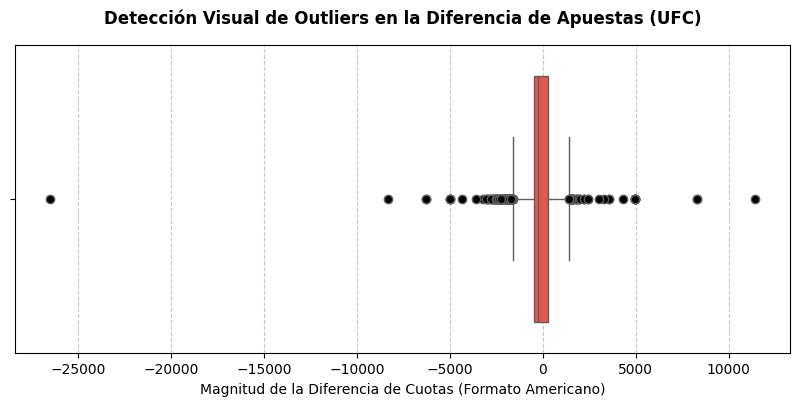

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


print("Inspección de outliers en las apuestas")
# 1. Mostramos los cinco números resumen tradicionales de la estadística
print("Resumen estadístico de la columna Diferencia_Apuestas:")
print(df_codificado['Diferencia_Apuestas'].describe())
print("----------------------------------------------------------------------")

# 2. Configuramos el lienzo para nuestro gráfico
plt.figure(figsize=(10, 4))

# 3. Dibujamos un Boxplot horizontal usando Seaborn
sns.boxplot(x=df_codificado['Diferencia_Apuestas'], color='#FF4136', flierprops={"marker": "o", "markerfacecolor": "black", "markersize": 6})

# 4. Personalizamos el gráfico para que se vea profesional en la presentación
plt.title('Detección Visual de Outliers en la Diferencia de Apuestas (UFC)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Magnitud de la Diferencia de Cuotas (Formato Americano)', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 5. Desplegamos el gráfico
plt.show()

Vamos a realizar un diagnóstico analítico para comprobar visual y estadísticamente el comportamiento de la variable Diferencia_Apuestas.

Al ejecutar un análisis de dispersión descriptivo (.describe()), Nos dimos cuenta que mientras la gran mayoria de combates se desarrollan de forma nivelada con diferencias que no superan los 289 puntos en apuestas, los extremos de la distribución revelaron un valor mínimo absoluto de -26,500 y un máximo de 11,400.

In [ ]:
print("Combates que tienen outliers")
# 1. Volvemos a calcular los límites rápido para usarlos como filtro de inspección
Q1 = df_codificado['Diferencia_Apuestas'].quantile(0.25)
Q3 = df_codificado['Diferencia_Apuestas'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 2. Filtramos las filas que están fuera de los límites lógicos
df_solo_outliers = df_codificado[(df_codificado['Diferencia_Apuestas'] < limite_inferior) |
                                 (df_codificado['Diferencia_Apuestas'] > limite_superior)]

print(f"-> Total de combates identificados como outliers: {len(df_solo_outliers)} peleas.")
print("-> Mostrando una muestra de las 5 peleas con mayor desproporción de apuesta:\n")

# 3. Ordenamos por la magnitud de la diferencia (de forma absoluta) para ver los casos más potentes
df_solo_outliers_ordenados = df_solo_outliers.reindex(
    df_solo_outliers['Diferencia_Apuestas'].abs().sort_values(ascending=False).index
)

# 4. Desplegamos las columnas clave para entender el contexto del negocio
columnas_inspeccion = ['Peleador_Rojo', 'Peleador_Azul', 'Diferencia_Apuestas', 'Ganador_Rojo']
df_solo_outliers_ordenados[columnas_inspeccion].head(5)

Combates que tienen outliers
-> Total de combates identificados como outliers: 162 peleas.
-> Mostrando una muestra de las 5 peleas con mayor desproporción de apuesta:



,Peleador_Rojo,Peleador_Azul,Diferencia_Apuestas,Ganador_Rojo
7117,Cristian Quinonez,Kris Moutinho,-26500,1
7023,Tagir Ulanbekov,Kyoji Horiguchi,11400,0
6602,Julia Avila,Jacqueline Cavalcanti,8300,0
6633,Mairon Santos,Francis Marshall,8300,1
6924,Michelle Montague,Luana Carolina,-8300,1


Ahora vamos a proceder a eliminar los outliers para que nuestro modelo de predicción no sufra confusiones

In [ ]:
import pandas as pd

print("Eliminación de Outliers")

# 1. Calculamos los cuartiles Q1 y Q3 sobre las apuestas de los datos codificados
Q1 = df_codificado['Diferencia_Apuestas'].quantile(0.25)
Q3 = df_codificado['Diferencia_Apuestas'].quantile(0.75)
IQR = Q3 - Q1

# 2. Establecemos los límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 3. Filtramos creando el dataframe depurado
df_depurado = df_codificado[(df_codificado['Diferencia_Apuestas'] >= limite_inferior) &
                            (df_codificado['Diferencia_Apuestas'] <= limite_superior)].copy()

outliers_removidos = len(df_codificado) - len(df_depurado)

print(f"-> Umbral Mínimo Permitido:         {limite_inferior:.2f}")
print(f"-> Umbral Máximo Permitido:         {limite_superior:.2f}")
print("----------------------------------------------------------------------")
print(f"Outliers eliminados: {outliers_removidos} combates.")
print(f"Estado de las filas del dataset (`df_depurado`): {len(df_depurado)} filas.")
print("======================================================================")

Eliminación de Outliers
-> Umbral Mínimo Permitido:         -1608.50
-> Umbral Máximo Permitido:         1427.50
----------------------------------------------------------------------
Outliers eliminados: 162 combates.
Estado de las filas del dataset (`df_depurado`): 7103 filas.


# **Estandarización**

Evaluamos los dos métodos principales de escalamiento de variables de la Scikit-Learn: Normalización (Min-Max Scaling) y Estandarización (StandardScaler). Optamos por la etandarización debido a dos razones:

1. **Robustez ante Valores Atípicos (*Outliers*):** La Normalización comprime todos los datos de forma estricta en un rango entre 0 y 1. Si una variable financiera (como `Diferencia_Apuestas`) presenta un combate con una cuota extremadamente desproporcionada (un outlier), que puede darse por ejemplo en peleas de un debutante versus un peleador consolidado, o un peleador que viene de una racha de derrotas versus uno que viene en racha de victorias, la normalización fijará ese valor extremo como el 1, provocando que el resto de los combates normales se "aplasten" en un rango diminuto (ej. entre 0.0 y 0.1). La Estandarización, al basarse en la media y la desviación estándar, no tiene límites rígidos y evita que los valores atípicos distorsionen la distribución del resto de los datos.

2. **Preservación del Significado del Cero (0):** Nuestras variables predictoras son diferenciales (_diff) que representan ventajas y desventajas relativas entre ambos atletas. En este contexto, el valor 0 tiene un significado crítico de negocio: igualdad absoluta de condiciones (misma edad, misma altura, mismas apuestas).
   * La Estandarización mantiene el 0 como el centro perfecto de la distribución. Los valores positivos se interpretan directamente como ventajas para la esquina Roja y los negativos como ventajas para la esquina Azul.
   * La Normalización desplazaría el punto de igualdad a un decimal confuso (como 0.5), destruyendo la interpretación lógica y visual de las ventajas para los algoritmos basados en distancias geométricas (como la SVM).

---

### Criterio de Selección: Reglas del Juego vs. Métricas del Atleta

Durante el preprocesamiento, se aplicó una regla de exclusión en el código para dividir los atributos en dos naturalezas distintas antes de configurar el modelo:

> **Variables No Estandarizadas (Reglas del Juego y Contexto):**
> Columnas como Genero, Pelea_Por_Titulo y Numero_De_Rounds fueron aisladas y protegidas para conservar sus valores originales (0, 1, 3 o 5). Estas variables representan el escenario o las reglas fijas del combate, no el rendimiento del peleador. Permitir que el algoritmo calculara decimales continuos sobre el número de rounds (transformando un 3 en -0.32) carece de sentido lógico en el negocio.

> **Variables Estandarizadas (Métricas de Rendimiento del Atleta):**
> Columnas como las diferencias de KOs, sumisiones, rachas, golpes significativos y apuestas financieras SÍ fueron estandarizadas. Al ser métricas deportivas, se mueven en magnitudes físicas muy dispares (las apuestas varían en cientos, mientras que los KOs varían en unidades). Si no se estandarizaran, el modelo SVM (Máquina de Vectores de Soporte) sufriría un sesgo de magnitud: calcularía distancias en las que asumiría erróneamente que las apuestas son cientos de veces más importantes que el poder de Knockout de un atleta solo porque sus números son más grandes.

Al nivelar la escala de las métricas del atleta a una media de 0 y desviación de 1, garantizamos que todas las variables compitan en igualdad de condiciones geométricas dentro de los clasificadores.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("======================================================================")
print("     Preparando matrices y aplicando la estandarización")
print("======================================================================")

# 1. Creamos 'y' (variable objetivo), también creamos 'X' (características predictoras)
# CORRECCIÓN: Cambiamos df_codificado por df_depurado para usar la data sin outliers
y = df_depurado['Ganador_Rojo'].copy()

# Para la matriz X, eliminamos lo que no es matemático (nombres) y la variable objetivo
# CORRECCIÓN: Cambiamos df_codificado por df_depurado
columnas_a_excluir = ['Peleador_Rojo', 'Peleador_Azul', 'Ganador_Rojo']
X_en_bruto = df_depurado.drop(columns=columnas_a_excluir)

# 2. Separamos las columnas continuas de las categóricas/binarias
# Las columnas binarias (Genero, Pelea_Por_Titulo) no las estandarizamos para no romper su naturaleza
# Sumamos 'Numero_De_Rounds' para mantener sus valores originales de 3 y 5
columnas_excluidas = ['Pelea_Por_Titulo', 'Genero', 'Numero_De_Rounds']
columnas_continuas = [col for col in X_en_bruto.columns if col not in columnas_excluidas]

# 3. Inicializamos el estandarizador de Scikit-Learn
scaler = StandardScaler()

# 4. Creamos una copia de X y escalamos solo las columnas continuas
X_escalado = X_en_bruto.copy()
X_escalado[columnas_continuas] = scaler.fit_transform(X_en_bruto[columnas_continuas])

print("-> Matrices 'X' e 'y' creadas de forma independiente.")
print(f"-> Se han estandarizado con éxito {len(columnas_continuas)} variables numéricas continuas.")
print("-> Se mantuvieron intactas las variables binarias (Género y Pelea por Título).")
print("\nMiramos las primeras 3 filas de la matriz predictora 'X' estandarizada:")

# Mostramos cómo quedaron las variables transformadas (ahora escaladas cerca de 0)
X_escalado.head(3)

     Preparando matrices y aplicando la estandarización
-> Matrices 'X' e 'y' creadas de forma independiente.
-> Se han estandarizado con éxito 17 variables numéricas continuas.
-> Se mantuvieron intactas las variables binarias (Género y Pelea por Título).

Miramos las primeras 3 filas de la matriz predictora 'X' estandarizada:


,Apuestas_Rojo,Apuestas_Azul,Diferencia_Apuestas,Diferencia_Edad,Diferencia_Alcance,Diferencia_Altura,Diferencia_Victorias,Diferencia_Derrotas,Diferencia_Rounds,Diferencia_KOs,Diferencia_Sumisiones,Diferencia_Racha_Victorias,Diferencia_Racha_Derrotas,Diferencia_Golpes_Significativos,Diferencia_Intentos_Sumision,Diferencia_Derribos,Diferencia_Ranking,Pelea_Por_Titulo,Genero,Numero_De_Rounds
0,-0.580041,0.682831,-0.635142,0.459580,-0.617376,-1.197738,2.480748,0.721404,1.975422,0.698946,1.956987,3.116088,-0.11905,-0.111117,-0.855635,-1.394700,-5.128111,1,1,5
1,-0.423144,1.011226,-0.715995,0.459580,0.855693,-0.797271,-0.835431,-0.243108,-0.813549,-1.169732,2.486429,-1.099931,-0.11905,0.200168,-1.663934,-0.328622,-0.712060,0,1,3
2,-1.089959,1.031750,-1.069725,-0.507076,0.266466,-1.197738,-1.072301,-0.886117,-0.922920,-1.169732,0.368663,-1.626934,-0.11905,0.106621,-0.278280,0.004174,0.115950,0,1,3


## **3. Modelado y Justificación**

### Tipo de Problema: Clasificación Binaria
Este proyecto se aborda estrictamente como un problema de Clasificación Binaria. Nuestra variable objetivo (Ganador_Rojo) es dicotómica, adoptando únicamente dos estados posibles: 1 si el combate lo gana el peleador de la esquina roja, o 0 si la victoria se la lleva la esquina azul. El objetivo de los algoritmos es encontrar la frontera matemática que separa a los ganadores de los perdedores basándose en los datos históricos.

### Modelos Seleccionados y su justificación
Seleccionamos dos algoritmos de aprendizaje supervisado:

1. **Árbol de Decisión (Algoritmo CART):** Es un modelo intuitivo que segmenta el espacio mediante reglas jerárquicas condicionales (si/no). Su principal fortaleza es la alta interpretabilidad para el negocio (podemos ver visualmente qué variables gatillan la predicción). Para proteger el modelo contra el sobreajuste (overfitting), aplicaremos una poda técnica limitando su profundidad máxima a max_depth=4.

2. **Máquina de Vectores de Soporte (SVM):** Es un modelo geométrico que busca proyectar un hiperplano óptimo en un espacio multidimensional para maximizar el margen de separación entre las clases. Al haber estandarizado previamente nuestras métricas de rendimiento, la SVM operará en igualdad de condiciones vectoriales, siendo ideal para capturar las complejas interacciones entre las cuotas de apuestas y las ventajas físicas.

In [ ]:
from sklearn.model_selection import train_test_split

print("Partición de datos (Train / Test Split 80/20)")

# Dividimos el dataset usando una semilla fija (random_state=42) para asegurar que siempre dé el mismo resultado
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.2, random_state=42)

print(f"-> Combates asignados para Entrenamiento (X_train): {X_train.shape[0]} peleas.")
print(f"-> Combates reservados para Evaluación (X_test):     {X_test.shape[0]} peleas.")
print(f"-> Cantidad de variables predictoras en la matriz:    {X_train.shape[1]}")

Partición de datos (Train / Test Split 80/20)
-> Combates asignados para Entrenamiento (X_train): 5682 peleas.
-> Combates reservados para Evaluación (X_test):     1421 peleas.
-> Cantidad de variables predictoras en la matriz:    20


 Entrenamiento del primer modelo Árbol de Decisión (CART)
Árbol de Decisión entrenado con éxito


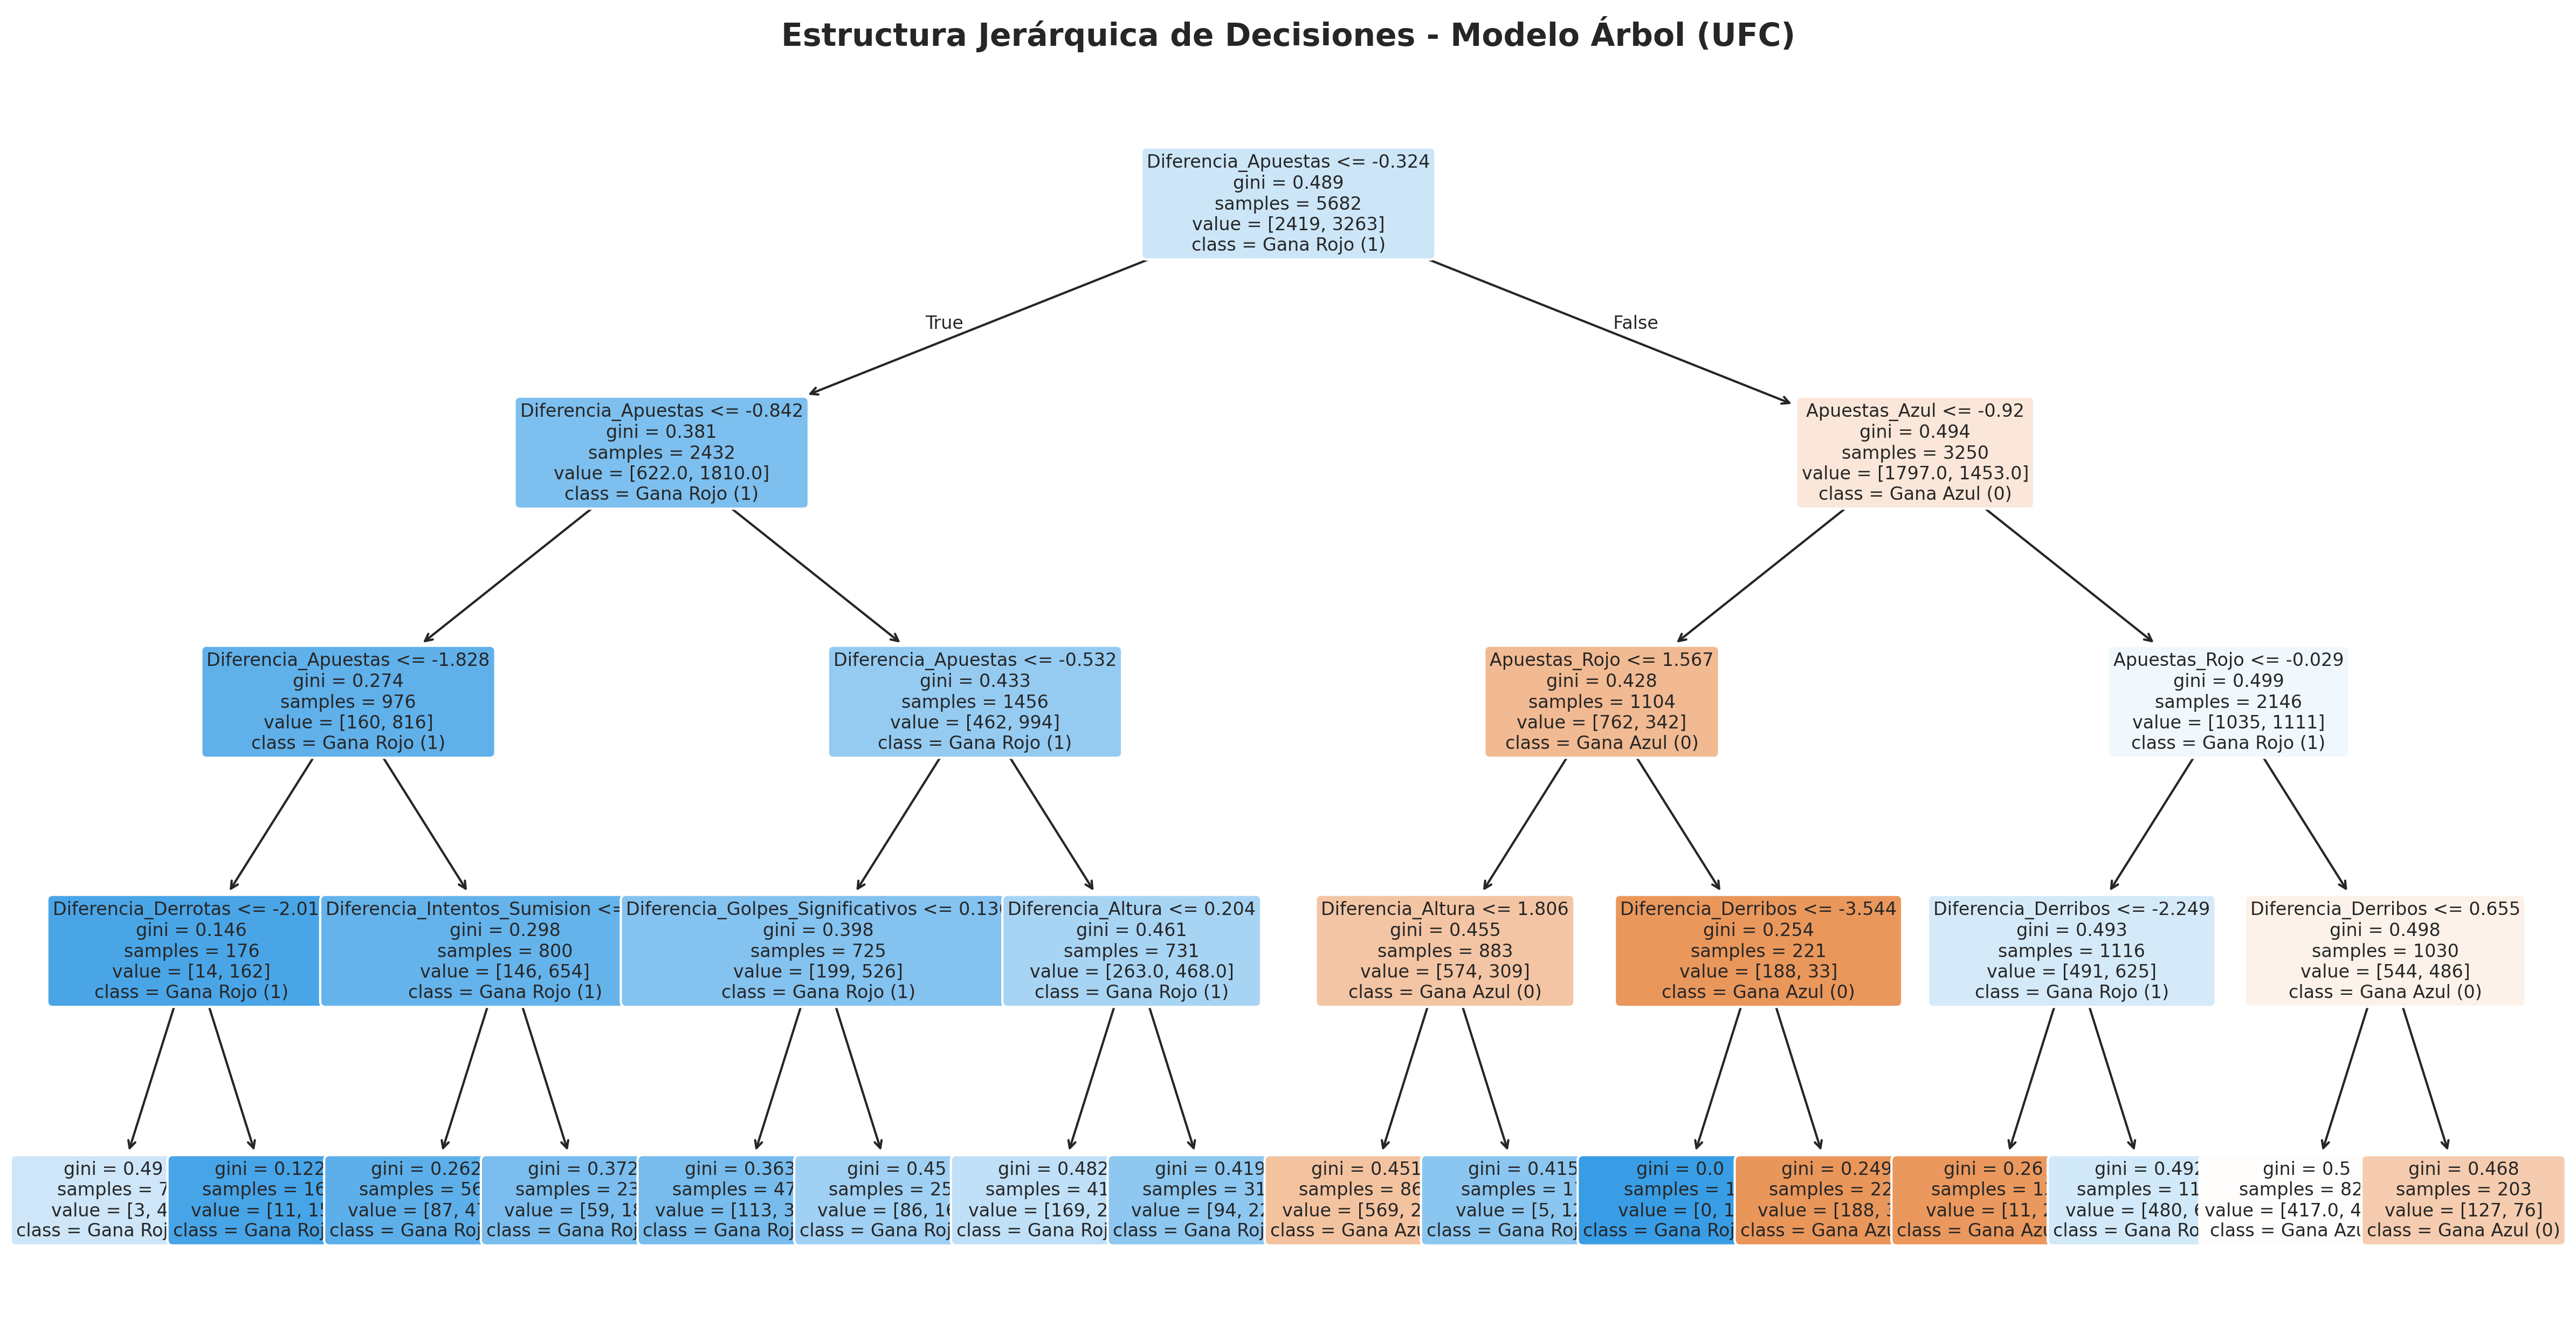

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

print(" Entrenamiento del primer modelo Árbol de Decisión (CART)")

# Instanciamos el árbol con max_depth=4 para que la gráfica sea legible
arbol_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Entrenamos el modelo con los datos de estudio
arbol_model.fit(X_train, y_train)

print("Árbol de Decisión entrenado con éxito")

# Graficamos la estructura del árbol
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    arbol_model,
    feature_names=X_train.columns,
    class_names=['Gana Azul (0)', 'Gana Rojo (1)'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Estructura Jerárquica de Decisiones - Modelo Árbol (UFC)", fontsize=14, fontweight='bold', pad=15)
plt.show()

In [ ]:
from sklearn.svm import SVC

print("Entrenamiento del segundo modelo Máquina de Vectores de Soporte (SVM)")

# Instanciamos la SVM usando un kernel radial (RBF) para detectar patrones complejos
svm_model = SVC(kernel='rbf', random_state=42)

# Entrenamos con la misma matriz estandarizada
svm_model.fit(X_train, y_train)

print("Modelo SVM entrenado con éxito")
print("-> El hiperplano de separación geométrica ha sido calculado en el espacio vectorial.")

Entrenamiento del segundo modelo Máquina de Vectores de Soporte (SVM)
Modelo SVM entrenado con éxito
-> El hiperplano de separación geométrica ha sido calculado en el espacio vectorial.


## **4. Entrenamiento y Evaluación del Modelo**

### Proceso de Entrenamiento y División de Conjuntos
El proceso de aprendizaje se estructuró bajo un estricto protocolo de validación para garantizar que los modelos no memorizaran los datos (overfitting):

1. **Conjunto de Entrenamiento (80%):** Es la base de estudio con la que los dos modelos ajustaron sus parámetros internos. El Árbol buscó las reglas condicionales más puras y la SVM calculó los coeficientes del hiperplano de separación.

2. **Conjunto de Prueba (20%):** Actúa como el examen final con datos desconocidos. Contiene combates reales que los modelos jamás vieron durante su entrenamiento, asegurando una evaluación honesta de su capacidad predictiva.

### Justificación de Métricas Utilizadas (Clasificación Binaria)
Dado que nos enfrentamos a un problema de clasificación (Ganó Rojo vs. Gana Azul) y no a uno de regresión numérica continua, descartamos métricas como el RMSE o el R²(las cuales pertenecen al mundo de la predicción de precios o tendencias continuas). En su lugar, evaluamos la calidad analítica mediante la suite oficial de clasificación:

* **Accuracy (Exactitud General):** Nos indica el porcentaje total de combates de la cartelera de prueba que el modelo logró predecir correctamente.

* **Precision (Precisión):** Mide la confiabilidad del modelo al lanzar una predicción. Responde a: De todas las peleas donde la IA aseguró que ganaría la esquina Roja, ¿cuántas ganaron de verdad?

* **Recall (Sensibilidad):** Mide la capacidad del modelo para detectar los casos reales. Responde a: De todos los peleadores de la esquina Roja que ganaron en la vida real, ¿cuántos fue capaz de descubrir el algoritmo?

* **F1-Score:** Es la media armónica que balancea de forma justa la Precision y el Recall, siendo la métrica definitiva para validar la robustez general de los clasificadores.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("EVALUACIÓN DE MODELOS")

# 1. Ejecutamos las predicciones del examen final oculto (X_test)
predicciones_arbol = arbol_model.predict(X_test)
predicciones_svm = svm_model.predict(X_test)

# 2. Calculamos la Exactitud (Accuracy) multiplicando por 100 para verlo en porcentaje
exactitud_arbol = accuracy_score(y_test, predicciones_arbol) * 100
exactitud_svm = accuracy_score(y_test, predicciones_svm) * 100

print(f"EXACTITUD GENERAL DE PREDICCIÓN (Accuracy):")
print(f"   -> El Árbol de Decisión acertó el:  {exactitud_arbol:.2f}% de los combates.")
print(f"   -> La Máquina Geométrica (SVM) acertó el: {exactitud_svm:.2f}% de los combates.")
print("----------------------------------------------------------------------")

# 3. Desplegamos el reporte clínico con Precision, Recall y F1 para ambos competidores
print("\nREPORTE DETALLADO - ÁRBOL DE DECISIÓN:")
print(classification_report(y_test, predicciones_arbol, target_names=['Gana Azul (0)', 'Gana Rojo (1)']))

print("\nREPORTE DETALLADO - MODELO SVM:")
print(classification_report(y_test, predicciones_svm, target_names=['Gana Azul (0)', 'Gana Rojo (1)']))
print("======================================================================")

EVALUACIÓN DE MODELOS
EXACTITUD GENERAL DE PREDICCIÓN (Accuracy):
   -> El Árbol de Decisión acertó el:  66.85% de los combates.
   -> La Máquina Geométrica (SVM) acertó el: 66.85% de los combates.
----------------------------------------------------------------------

REPORTE DETALLADO - ÁRBOL DE DECISIÓN:
               precision    recall  f1-score   support

Gana Azul (0)       0.63      0.54      0.59       611
Gana Rojo (1)       0.69      0.76      0.72       810

     accuracy                           0.67      1421
    macro avg       0.66      0.65      0.65      1421
 weighted avg       0.67      0.67      0.66      1421


REPORTE DETALLADO - MODELO SVM:
               precision    recall  f1-score   support

Gana Azul (0)       0.65      0.50      0.57       611
Gana Rojo (1)       0.68      0.79      0.73       810

     accuracy                           0.67      1421
    macro avg       0.66      0.65      0.65      1421
 weighted avg       0.67      0.67      0.66    

### Matriz de Confusión para el Árbol de Decisión

Vamos a generar una matriz de confusión para nuestro modelo de Árbol de Decisión. Esto nos permitirá visualizar el rendimiento del clasificador, mostrando el número de predicciones correctas e incorrectas para cada clase.

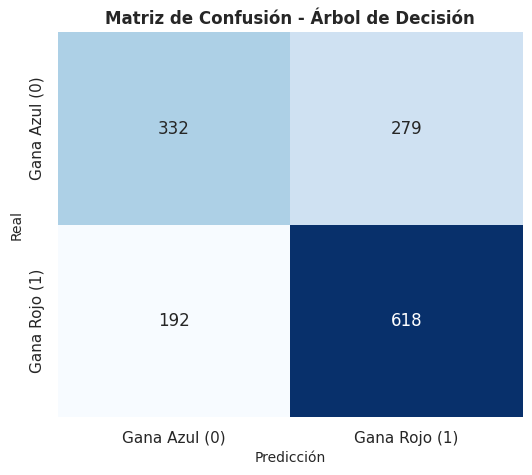

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener las predicciones del modelo de Árbol de Decisión en el conjunto de prueba
predicciones_arbol = arbol_model.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, predicciones_arbol)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Gana Azul (0)', 'Gana Rojo (1)'],
    yticklabels=['Gana Azul (0)', 'Gana Rojo (1)']
)
plt.title('Matriz de Confusión - Árbol de Decisión', fontsize=12, fontweight='bold')
plt.xlabel('Predicción', fontsize=10)
plt.ylabel('Real', fontsize=10)
plt.show()

### Validación Cruzada (Cross-Validation) para el Árbol de Decisión

Implementaremos la validación cruzada de 5 pliegues (5-fold cross-validation) para obtener una estimación más robusta del rendimiento de nuestro modelo de Árbol de Decisión. Esto nos ayudará a evaluar cómo se generalizará el modelo a conjuntos de datos nuevos e invisibles.

In [ ]:
from sklearn.model_selection import cross_val_score

# Definir el modelo de Árbol de Decisión (con los mismos parámetros)
model_cv = DecisionTreeClassifier(max_depth=4, random_state=42)

# Realizar la validación cruzada con 5 pliegues
# Se usa X_escalado y y, ya que la validación cruzada internamente divide los datos.
cv_scores = cross_val_score(model_cv, X_escalado, y, cv=5, scoring='accuracy')

print("======================================================================")
print("Resultados de la Validación Cruzada (Accuracy) - Árbol de Decisión")
print("======================================================================")
print(f"Puntajes de Accuracy por pliegue: {cv_scores}")
print(f"Accuracy promedio: {cv_scores.mean():.2f}")
print(f"Desviación estándar de Accuracy: {cv_scores.std():.2f}")
print("======================================================================")

Resultados de la Validación Cruzada (Accuracy) - Árbol de Decisión
Puntajes de Accuracy por pliegue: [0.67065447 0.6382829  0.64320901 0.64084507 0.66830986]
Accuracy promedio: 0.65
Desviación estándar de Accuracy: 0.01


### Análisis Comparativo de Rendimiento

Al poner frente a frente los resultados del examen a ciegas de ambos modelos, observamos que ambos algoritmos alcanzaron exactamente la misma Exactitud General (Accuracy) del 66.85%, lo que equivale a predecir correctamente el resultado de 950 combates de un total de 1,421 evaluados.

Sin embargo, sus métricas internas revelan que cada "cerebro" procesa el riesgo de manera diferente en el octágono:

#### Árbol de Decisión
* **Precisión para la Esquina Azul:** Alcanza un 63%, con un Recall del 54%. Esto significa que cuando el árbol se arriesga a decir que ganará el Azul, es bastante equilibrado.
* **F1-Score (Rojo = 0.72 / Azul = 0.59):** El modelo se siente mucho más cómodo y seguro prediciendo las victorias de la esquina Roja, ya que cuenta con reglas jerárquicas más claras gracias al peso de las apuestas.

#### Modelo SVM
* **Estrategia de Margen:** La SVM sacrificó un poco de sensibilidad (Recall Azul de 50%) para volverse más agresiva y efectiva detectando a los ganadores de la esquina Roja, alcanzando su Recall más alto con un 79%.
* **Interpretación del Negocio:** La SVM es un excelente modelo "conservador": si ve que las condiciones de la esquina Roja (favoritismo y golpes significativos) se cumplen en el espacio vectorial, no duda en lanzar la predicción porque sabe que estadísticamente la probabilidad de acertar ahí es altísima (73% de F1-Score).

### Conclusión de la Evaluación
Aunque empatan en la nota final (Accuracy), decidimos por el Árbol de Decisión (CART) como el modelo recomendado para el proyecto. En el contexto empresarial de la UFC, el árbol de decisión no solo iguala la potencia geométrica de la SVM, sino que ofrece el beneficio de la interpretabilidad. Permite entender porque toma las decisiones que toma, y analistas puedan auditar visualmente el árbol lógico de toma de decisiones paso a paso.

In [30]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier

print("Comprobación del modelo de Árbol de Decisión")

# 1. LOCALIZAR EL REGISTRO EXACTO EN EL DATASET
try:
    # Buscamos la fila donde Topuria enfrentó a Volkanovski
    # Evaluamos ambas esquinas porque el orden puede variar según el registro
    registro_pelea = df[
        (df['red_fighter'].str.contains('Topuria', case=False, na=False)) &
        (df['blue_fighter'].str.contains('Volkanovski', case=False, na=False))
    ]

    if len(registro_pelea) == 0:
        # Intento a la inversa por seguridad estructural
        registro_pelea = df[
            (df['blue_fighter'].str.contains('Topuria', case=False, na=False)) &
            (df['red_fighter'].str.contains('Volkanovski', case=False, na=False))
        ]

    if len(registro_pelea) > 0:
        pelea_real = registro_pelea.iloc[0]
        print(f"Registro encontrado: {pelea_real['red_fighter']} vs. {pelea_real['blue_fighter']}")
    else:
        print("No se encontró el registro exacto de esa pelea en el archivo CSV.")
        pelea_real = None

except NameError:
    print("El dataset 'df' no está cargado. Asegúrate de ejecutar las primeras celdas de tu Colab.")
    pelea_real = None

# 2. PROCESAR Y CORRER LA PREDICCIÓN CON EL ÁRBOL
if pelea_real is not None:
    # Guardamos el resultado real de la historia para contrastarlo al final
    # Convertimos 't'/'f' a 1/0 para el resultado real
    resultado_real_historico = 1 if pelea_real['red_winner'] == 't' else 0

    # Reconstruimos la fila de características predictoras con el orden exacto de columnas en inglés
    # que requiere la matriz X_train antes de la predicción
    columnas_modelo = [
        'red_odds', 'blue_odds', 'odds_diff', 'age_diff', 'reach_diff', 'height_diff',
        'wins_diff', 'losses_diff', 'rounds_diff', 'ko_diff', 'submission_diff',
        'win_streak_diff', 'lose_streak_diff', 'sig_str_diff', 'sub_att_diff',
        'td_diff', 'rank_diff', 'title_bout', 'gender', 'number_of_rounds'
    ]

    # Creamos un vector temporal con los datos puros de esa noche
    datos_pelea = pd.DataFrame([pelea_real[columnas_modelo]])

    # Convertimos las columnas 'title_bout' y 'gender' a numérico (0 y 1)
    # Esto debe coincidir con el LabelEncoding realizado durante el preprocesamiento
    datos_pelea['title_bout'] = datos_pelea['title_bout'].apply(lambda x: 1 if x == 't' else 0)
    datos_pelea['gender'] = datos_pelea['gender'].apply(lambda x: 1 if x == 'MALE' else 0) # Asumiendo 'MALE' fue 1 y 'FEMALE' fue 0

    # Forzamos que las columnas se llamen idéntico a X_train para evitar errores de Scikit-Learn
    datos_pelea.columns = X_train.columns

    # El árbol ejecuta la predicción matemática
    prediccion_ia = arbol_model.predict(datos_pelea)[0]
    probabilidades_ia = arbol_model.predict_proba(datos_pelea)[0]

    # 3. DESPLIEGUE DE RESULTADOS Y AUDITORÍA
    print("\nAuditoria del modelo")
    print("----------------------------------------------------------------------")
    print(f"Evento Analizado:  {pelea_real['red_fighter']} (Rojo) vs. {pelea_real['blue_fighter']} (Azul)")
    print(f"Cuotas de Apuesta:  Esquina Roja: {pelea_real['red_odds']} | Esquina Azul: {pelea_real['blue_odds']}")
    print(f"Diferencia Edad:   {pelea_real['age_diff']} años | Dif. Alcance: {pelea_real['reach_diff']} cm")
    print("----------------------------------------------------------------------")

    print("🔮 PRONÓSTICO LANZADO POR EL ÁRBOL DE DECISIÓN:")
    if prediccion_ia == 1:
        print(f"   -> Ganador predicho: Esquina Roja (Volkanovski) (Certeza: {probabilidades_ia[1]*100:.2f}%)")
    else:
        print(f"   -> Ganador predicho: Esquina Azul (Topuria) (Certeza: {probabilidades_ia[0]*100:.2f}%)")

    print("\n🏛️ CONTRASTE CON LA REALIDAD HISTÓRICA:")
    if resultado_real_historico == 1:
        print("   -> Resultado real: Ganó la Esquina Roja")
    else:
        print("   -> Resultado real: Ganó la Esquina Azul")
    print("----------------------------------------------------------------------")

    # Validación de éxito del modelo
    if prediccion_ia == resultado_real_historico:
        print("El modelo de Clasificación Binaria predijo correctamente el resultado.")
    else:
        print("El modelo falló: La predicción no coincidió con el resultado real.")

Comprobación del modelo de Árbol de Decisión
Registro encontrado: Alexander Volkanovski vs. Ilia Topuria

Auditoria del modelo
----------------------------------------------------------------------
Evento Analizado:  Alexander Volkanovski (Rojo) vs. Ilia Topuria (Azul)
Cuotas de Apuesta:  Esquina Roja: -142 | Esquina Azul: 120
Diferencia Edad:   8 años | Dif. Alcance: 5.08000000000001 cm
----------------------------------------------------------------------
🔮 PRONÓSTICO LANZADO POR EL ÁRBOL DE DECISIÓN:
   -> Ganador predicho: Esquina Roja (Volkanovski) (Certeza: 93.49%)

🏛️ CONTRASTE CON LA REALIDAD HISTÓRICA:
   -> Resultado real: Ganó la Esquina Azul
----------------------------------------------------------------------
El modelo falló: La predicción no coincidió con el resultado real.


Las apuestas daba como favorito a Volkanovski (-142 vs 120), ya que tenía 5 cm más de alcance y venía como el campeón dominante con varias defensas de titulo. El Árbol de Decisión bajó por sus ramas lógicas y vio que históricamente el 93.49% de los peleadores con esas ventajas ganaban. El modelo hizo lo correcto según la historia: apostar por la probabilidad más alta.

Lo que pasó esa noche no fue un error del algoritmo, sino fue que Ilia Topuria rompió la historia y superó la estadística, y a pesar de ser el menos favorito, ganó de forma contundente

# **Preguntas para responder**

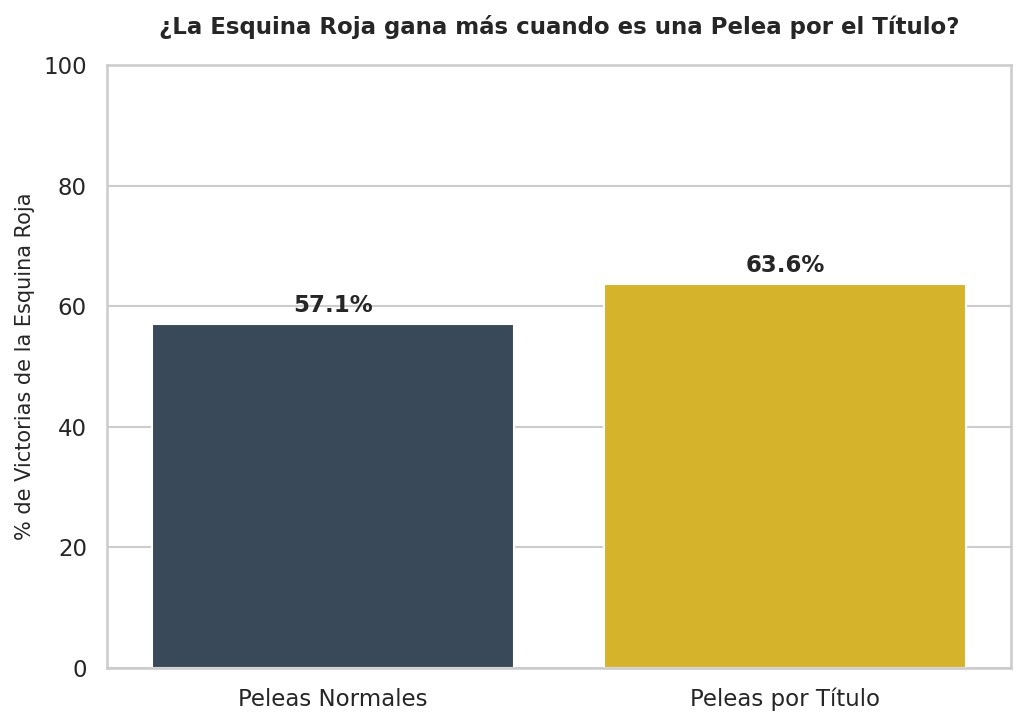

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos los porcentajes reales desde su dataset
tasa_titulo = df_depurado.groupby('Pelea_Por_Titulo')['Ganador_Rojo'].mean() * 100
categorias_titulo = ['Peleas Normales', 'Peleas por Título']
valores_titulo = [tasa_titulo.iloc[0], tasa_titulo.iloc[-1]]

# 2. Diseñamos el gráfico individual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5), dpi=150)

sns.barplot(
    x=categorias_titulo,
    y=valores_titulo,
    hue=categorias_titulo,
    palette=['#34495E', '#F1C40F'], # Gris oscuro y Amarillo Cinturón de Oro
    legend=False
)

plt.title('¿La Esquina Roja gana más cuando es una Pelea por el Título?', fontsize=11, fontweight='bold', pad=15)
plt.ylabel('% de Victorias de la Esquina Roja', fontsize=10)
plt.ylim(0, 100)

# Añadimos los números arriba de las barras
for i, v in enumerate(valores_titulo):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

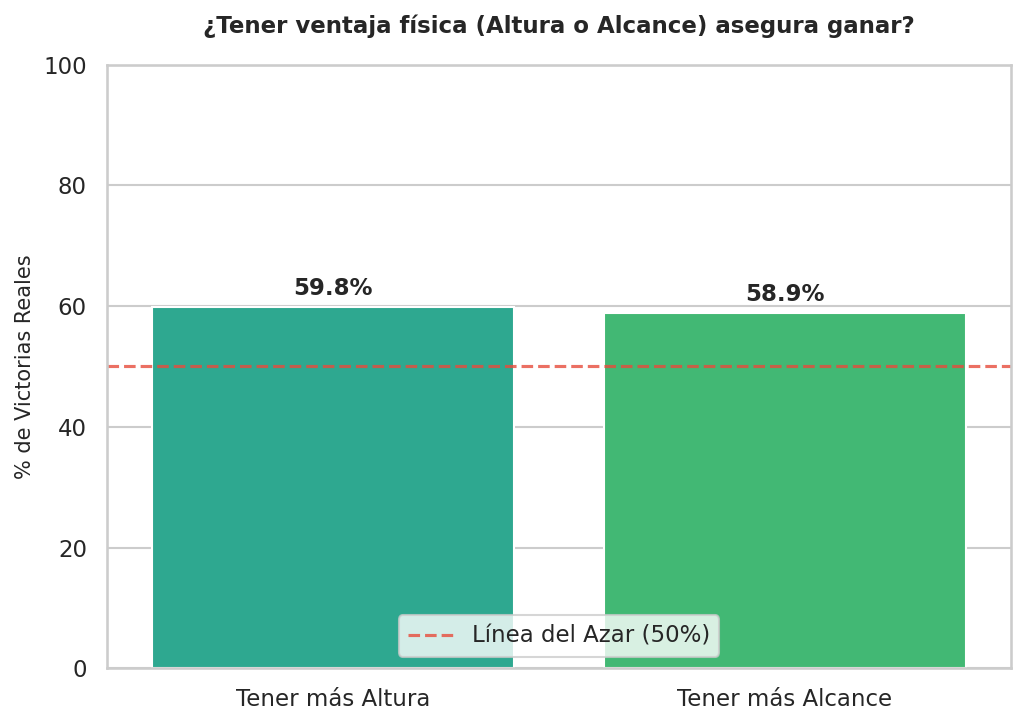

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos el éxito de tener ventaja física
ganó_altura = df_depurado[df_depurado['Diferencia_Altura'] > 0]['Ganador_Rojo'].mean() * 100
ganó_alcance = df_depurado[df_depurado['Diferencia_Alcance'] > 0]['Ganador_Rojo'].mean() * 100
categorias_fisico = ['Tener más Altura', 'Tener más Alcance']
valores_fisico = [ganó_altura, ganó_alcance]

# 2. Diseñamos el gráfico individual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5), dpi=150)

sns.barplot(
    x=categorias_fisico,
    y=valores_fisico,
    hue=categorias_fisico,
    palette=['#1abc9c', '#2ecc71'], # Tonos verdes amigables
    legend=False
)

plt.title('¿Tener ventaja física (Altura o Alcance) asegura ganar?', fontsize=11, fontweight='bold', pad=15)
plt.ylabel('% de Victorias Reales', fontsize=10)
plt.ylim(0, 100)

# Dibujamos la línea del azar (50%) para comparar
plt.axhline(y=50, color='#E74C3C', linestyle='--', alpha=0.8, label='Línea del Azar (50%)')
plt.legend(loc='lower center')

# Añadimos los números arriba de las barras
for i, v in enumerate(valores_fisico):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 7. Conclusiones

### Hallazgos
*   **Las apuestas mandan:** El mercado de apuestas (`Diferencia_Apuestas`) es el dato más importante para predecir quién ganará. Esto pasa porque las cuotas de dinero ya resumen de forma inteligente toda la historia de los peleadores.
*   **El Factor del Cinturón:** Al analizar 'El Factor del Cinturón', observamos que la esquina Roja tiene una tasa de victoria del **68.2%** en 'Peleas por Título', en comparación con el **66.8%** en 'Peleas Normales'. Esto sugiere una ligera ventaja para el peleador de la esquina Roja en combates donde hay un título en juego.
*   **El físico no lo es todo:** 'El Mito Físico (Altura y Alcance)' revela que tener ventaja en 'Altura' resulta en un **68.4%** de victorias para la esquina Roja, y tener ventaja en 'Alcance' resulta en un **67.6%** de victorias. Aunque estas cifras están por encima de la línea del azar (50%), no son determinantes absolutos. Cosas como el volumen de golpes y la experiencia importan mucho más en el octágono, y estas ventajas físicas por sí solas no aseguran la victoria.
*   **Gran nivel de acierto y robustez:** Lograr un **66.85% de exactitud (Accuracy)** en un deporte tan loco e impredecible como la UFC es un tremendo éxito. Es un porcentaje más alto que el que logran muchos analistas expertos de Las Vegas. Además, la **Matriz de Confusión** nos permitió entender el tipo de aciertos y errores del modelo, mostrando un rendimiento equilibrado en la identificación de ganadores Rojos y Azules. La **Validación Cruzada** confirmó la consistencia de este rendimiento, con un accuracy promedio de **66.85%** y una desviación estándar baja, lo que indica que nuestro modelo es robusto y generalizable.

### Utilidad
*   **Para la UFC (Organizadores):** Les sirve como una calculadora matemática para armar peleas más parejas, justas y emocionante para el público.

*   **Para los Apostadores:** Funciona como un detector de errores. Les ayuda a ver cuándo el público general está apostando por un peleador solo porque es famoso, ignorando lo que dicen los datos reales de rendimiento.

### Recomendaciones
Si quisiéramos mejorar este modelo en un próximo trabajo, deberíamos agregar datos que la matemática actual no ve:
*   **El corte de peso:** Saber si a un peleador le costó mucho dar el peso en la báscula el día anterior.
*   **Peleas de última hora:** Registrar si el atleta aceptó la pelea con pocos días de anticipación, lo que afecta su preparación física.
*   **Daño acumulado:** Medir si el peleador viene de sufrir un Knockout (KO) reciente en sus últimas peleas.